In [1]:
import json
from langgraph.graph import StateGraph ,START , END
from langchain_mistralai import ChatMistralAI
from langchain_community.tools import  DuckDuckGoSearchRun
from langchain_community.tools import DuckDuckGoSearchResults
from typing import TypedDict
from dotenv import load_dotenv

C:\Users\hp\AppData\Local\Temp\ipykernel_328\19705708.py:4: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import  DuckDuckGoSearchRun


In [2]:
load_dotenv()
model = ChatMistralAI(model_name="ministral-3b-latest", temperature=0.7)

In [3]:
class travel(TypedDict):
    country:str
    forecast : list
    weather:str
    summary:str

In [4]:
def forecast(state:travel)->travel:
    country = state['country']
    search_tool = DuckDuckGoSearchResults(output_format="list")
    forecast = search_tool.invoke(f"current temperature in {country}")
    state['forecast'] = forecast
    return state

In [5]:
def fetch(state: travel) -> travel:
    raw_results = state['forecast']
    
    # Simple extraction prompt to trim the noise
    extraction_prompt = (
        f"Extract ONLY the current temperature and conditions from these web results. "
        f"Be direct and brief:\n\n{json.dumps(raw_results, indent=4)}"
    )
    
    # Run the LLM to get a clean text snippet
    state['weather'] = model.invoke(extraction_prompt).content
    return state

In [6]:
# 4. NODE 3: MAKE THE FINAL RECOMMENDATION
def summary(state: travel) -> travel:
    clean_weather = state['weather']
    prompt = f"The current weather there is: {clean_weather}. sugget as a travel agent : Should I travel there right now? Give a quick summary."
    state['summary'] = model.invoke(prompt).content
    return state

In [7]:
graph = StateGraph(travel)
graph.add_node("Forecast", forecast)
graph.add_node("Fetch_temp", fetch)
graph.add_node("Travel Agent", summary)

# Connect the pipeline paths sequentially
graph.add_edge(START, 'Forecast')
graph.add_edge('Forecast', 'Fetch_temp')     # Raw data goes to extractor
graph.add_edge('Fetch_temp', 'Travel Agent')  
graph.add_edge('Travel Agent',END)

workflow = graph.compile()


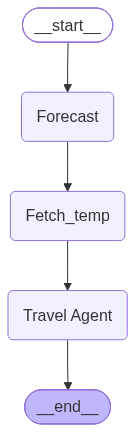

In [8]:
from IPython.display import Image, display 
display(Image(workflow.get_graph().draw_mermaid_png()))

In [9]:
start = {'country': "paris"}
end = workflow.invoke(start)
print(end['summary'])


**Quick Travel Recommendation for Now:**

✅ **Yes, go!** The warm (~26.7°C/80°F) and sunny weather is perfect for sightseeing, outdoor activities, or relaxation. Pack light layers (light jacket/hoodie for slight evening cool) and sunscreen.

⚠️ **Check ahead:**
- Verify if flights/accommodation are still available (hot weather can impact bookings).
- Confirm if local events (festivals, closures) align with your travel dates.

**Best for:** Beach trips, city tours, hiking, or cultural visits. Enjoy!
